In [1]:
import numpy as np
import numba as nb
import matplotlib.pyplot as plt

from pyproj import Transformer
import pandas as pd
import xarray as xr

from pathlib import Path
import os
from tqdm import tqdm

from topocalc import gradient
from topocalc import viewf
from topocalc import horizon
import pvlib

A faire :
    
    Faire tout les à faire des autres sections
    Tout mettre dans un fichier functions.py
    Ecrire un script qui prend des arguments pour tourner dans un run dir
    pip freeze du venv avec lequel ça fonctionne
    établir une liste exhaustive des fichiers nécessaires

# LW

A faire : 
    
    Vérifier que le truc tourne avec des forçages AROME
    Où trouver la température de surface Ts diagnostiquée par AROME ? Même fichier de forçage ?
    
    Calculer l'émissivité sur la base de sortie AROME pour moduler l'émission LW par l'atm

OK : 

    Rajouter un cropped pour spécifier une zone --> cropped le DEM et le le forçage
    Changer de coordonnées les forçage pour Lambert 93 ?
    Descendre d'échelle la température de surface avec un gradiant atmosphérique ?
    AROME ne connaît pas l'émissivité de la surface, mais bien la température -> forcer un modèle de surface par AROME ou oublier la permitivité ? --> Prendre la température de surface de AROME
    Identifier l'epsg des fichiers AROME : 4326
    Rajouter les multiples pas de temps
    Enlever la dépedance à l'émissivité de la surface : $\epsilon$ = 1 partout
    Enlever la projection des données en 32632 : inutile si le produit de base est en Lambert 93
    

In [2]:
############################ Functions ####################################

######## Select area ##########

def crop_dataset(
    fic_to_ds : str,
    epsg_i : int,
    epsg_ds : int,
    x_dim,
    y_dim,
    xmin = None,
    xmax = None,
    ymin = None,
    ymax = None,
    )-> xr.Dataset :
    
    ds = xr.open_dataset(fic_to_ds)
    
    # Reindexing on increasing coordinates 
    ds = ds.sortby(x_dim)
    ds = ds.sortby(y_dim)

    if epsg_i != epsg_ds :
        xmin,ymin = convert_epsg_pts(xmin,ymin, epsg_src = epsg_i, epsg_tgt=epsg_ds)
        xmax,ymax = convert_epsg_pts(xmax,ymax, epsg_src = epsg_i, epsg_tgt=epsg_ds)
        
    ds = ds.sel({x_dim: slice(xmin, xmax), y_dim: slice(ymin, ymax)})
    
    return ds

def slice_by_time(ds: xr.Dataset,
                  start: str | pd.Timestamp,
                  stop:  str | pd.Timestamp,
                  dim: str = "valid_time") -> xr.Dataset:
    
    if dim not in ds.coords:
        raise KeyError(f"'{dim}' n’est pas une coordonnée du dataset "
                       f"(coordonnées disponibles : {list(ds.coords)})")

    start_ts = pd.to_datetime(start)
    stop_ts  = pd.to_datetime(stop)

    ds_slice = ds.sel({dim: slice(start_ts, stop_ts)})

    return ds_slice

######## Interpolation #########

@nb.njit()
def find_closest(arr: np.ndarray, 
                 val: float) -> int:
    """
    [Input]
    - array 1D rangé dans l'ordre croissant
    - valeur
    [Output]
    - index tel que arr[i] <= val < arr[i+1]
    """
    a, b = 0, arr.shape[0] - 2          # on veut l'index gauche
    while a < b:
        milieu = (a + b + 1) // 2
        if arr[milieu] <= val:
            a = milieu
        else:
            b = milieu - 1
    return a

@nb.njit()
def bilinear_interpolation(
    xs: np.ndarray, 
    ys: np.ndarray,
    arr: np.ndarray,
    points: np.ndarray,
    ) -> np.ndarray:
    """
    [Input]
    - coordonnées x de la grille (Nx,) triées croissantes
    - coordonnées y de la grille (Ny,) triées croissantes
    - array (Ny, Nx) des valeurs à interpoler pour chaque points de la grille 
    - points cibles (N, 3)  colonnes x, y, z
    
    [Output]
    - (N,) de valeurs SVF interpolées (NaN si hors grille)
    """
    N = points.shape[0]
    result = np.empty(N, dtype=np.float64)
 
    x_min, x_max = xs[0], xs[-1]
    y_min, y_max = ys[0], ys[-1]
 
    for k in range(N):
        px = points[k, 0]
        py = points[k, 1]
 
        # Hors domaine renvoit NaN
        if px < x_min or px > x_max or py < y_min or py > y_max:
            result[k] = np.nan
            continue
 
        ix = find_closest(xs, px)
        iy = find_closest(ys, py)
        
        # Renvoit un Nan si les proches voisins sont des Nan
        if (np.isnan(arr[iy,ix]) == True or arr[iy+1,ix+1] == True or
            arr[iy+1,ix] == True or arr[iy,ix+1] == True):
            
            result[k] = np.nan
            continue
            
        x0, x1 = xs[ix], xs[ix + 1]
        y0, y1 = ys[iy], ys[iy + 1]
 
        # Poids de pondération = distance relative à l'écart entre les proches voisins
        tx = (px - x0) / (x1 - x0)
        ty = (py - y0) / (y1 - y0)
 
        # Coins de la cellule  arr[iy, ix] → ligne = y, colonne = x
        res00 = arr[iy,     ix    ]
        res10 = arr[iy,     ix + 1]
        res01 = arr[iy + 1, ix    ]
        res11 = arr[iy + 1, ix + 1]
 
        result[k] = (
            res00 * (1 - tx) * (1 - ty)
            + res10 *      tx  * (1 - ty)
            + res01 * (1 - tx) *      ty
            + res11 *      tx  *      ty
        )
 
    return result

@nb.njit()
def interpolate(
    xs : np.ndarray,
    ys : np.ndarray,
    arr : np.ndarray,
    points: np.ndarray,
    ) -> np.ndarray:
    """
    [Input]
    - xs : valeurs 1D des abscisses du tableau
    - ys : valeurs 1D des ordonnées du tableau
    - arr : tableau 2D des valeurs à interpoler
    - points : ndarray des points où interpoler (Nbre_points, 2) (x,y)
    [Output]
    - np.ndarray (N,) de valeurs interpolées (Nan hors domaine)
    """
    
    # Garantit que les axes sont croissants pour si jamais sortie de xarray
    if xs[-1] < xs[0]:
        xs  = xs[::-1].copy()
        arr = arr[:, ::-1].copy()
    if ys[-1] < ys[0]:
        ys  = ys[::-1].copy()
        arr = arr[::-1, :].copy()
 
    pts = np.ascontiguousarray(points)#, dtype=np.float64)
 
    return bilinear_interpolation(xs, ys, arr, pts)

########### Altitude gradiant for temperature ###########

def altitudinal_gradiant(
    diff_ZS : float | np.ndarray, #ZS fine - ZS coarse
    Ts : float | np.ndarray, # Ts coarse interpolé sur la grille fine
    )-> float | np.ndarray: # Ts fine corrigé par un laspe rate moyen tropospherique
    
    laspe_rate = -6.5e-3 #K/m
    
    return Ts + diff_ZS*laspe_rate

########### SVF ###################

def convert_epsg_pts(xs,ys, epsg_src, epsg_tgt=32632):
    """
    Simple function to convert a list fo poitn from one projection to another oen using PyProj

    Args:
        xs (array): 1D array with X-coordinate expressed in the source EPSG
        ys (array): 1D array with Y-coordinate expressed in the source EPSG
        epsg_src (int): source projection EPSG code
        epsg_tgt (int): target projection EPSG code

    Returns: 
        array: Xs 1D arrays of the point coordinates expressed in the target projection
        array: Ys 1D arrays of the point coordinates expressed in the target projection
    """
    #print('Convert coordinates from EPSG:{} to EPSG:{}'.format(epsg_src, epsg_tgt))
    trans = Transformer.from_crs("epsg:{}".format(epsg_src), "epsg:{}".format(epsg_tgt), always_xy=True)
    Xs, Ys = trans.transform(xs, ys)
    return Xs, Ys

def compute_svf_regular_grid(
    fic_topo : str,
    fic_save : str,
    xmin : float,
    xmax : float,
    ymin : float,
    ymax : float,    
    epsg_i = 4326,
    epsg_ds = 2154,    
    ):
    
    ds_topo = crop_dataset(
        fic_to_ds = fic_topo,
        xmin = xmin,
        xmax = xmax,
        ymin = ymin,
        ymax = ymax,
        epsg_i = epsg_i,
        epsg_ds = epsg_ds,
        x_dim = "x",
        y_dim = "y"
        )
    
    dem_arr = ds_topo.ZS.values
    
    # La projection Lambert 93 (ou epsg 2154) est en mètre donc conforme pour le calcul, pas besoin de changer en 32632
    #xs, ys = convert_epsg_pts(ds_topo.x.values,ds_topo.x.values, epsg_src = epsg_init, epsg_tgt=32632)
    dx = np.median(np.diff(ds_topo.x.values))
    dy = np.median(np.diff(ds_topo.y.values))

    svf = viewf.viewf(np.double(dem_arr), dx)[0]
    slope, aspect = gradient.gradient_d8(dem_arr, dx, dy)
    
    # Sauvegarde sous .nc
    ds_topo_params = xr.Dataset(
        data_vars=dict(
            ZS=(["y", "x"], dem_arr.astype(np.float64)),
            svf=(["y", "x"], svf.astype(np.float64)),
            slope=(["y", "x"], slope.astype(np.float64)),
            aspect=(["y", "x"], aspect.astype(np.float64)),
        ),
        coords=dict(
            x=("x", ds_topo.x.values),
            y=("y", ds_topo.y.values),
        )
    )
    ds_topo_params.ZS.attrs={'units': 'm', 'standard_name': 'elevation', 'long_name': 'elevation'}
    ds_topo_params.x.attrs = {'units': 'm'}
    ds_topo_params.y.attrs = {'units': 'm'}
    ds_topo_params.slope.attrs = {'units': 'rad'}
    ds_topo_params.aspect.attrs = {'units': 'rad'}
    ds_topo_params.svf.attrs = {'units': 'ratio', 'standard_name': 'svf', 'long_name': 'Sky view factor'}
    ds_topo_params.to_netcdf(fic_save)

########### Rayonnement ############
    
sigma = 5.67e-8

@nb.njit()
def Downscale_lw_u(
    Ts : np.ndarray, # res cible
    Eps : np.ndarray, # res cible
    LWd : np.ndarray, # res cible
    xs : np.ndarray,
    ys : np.ndarray,
    delta = 2000,
    )-> np.ndarray:
    
    nx, ny = xs.shape
    LWu = np.zeros((nx, ny))
    
    for i in range(nx):
        for j in range(ny):
            mask = (xs-xs[i,j])**2 + (ys-ys[i,j]) <= delta**2
            LWu[i,j] = np.mean((1-Eps[mask])*LWd[mask] + Eps[mask]*sigma*Ts[mask]**4)
            
    return LWu
    
@nb.njit()
def LW( # Que des nd.array 2D de même dimension que la topo cible
    eps_fine : np.ndarray,
    eps_a : np.ndarray,
    Ta_fine : np.ndarray,
    Ts_fine : np.ndarray,
    SVF : np.ndarray,
    xx : np.ndarray,
    yy : np.ndarray,
    ):
    """
    [Input]
        - Données à la résolution cibles
    [Output]
        - LW résolution cible
    """
    
    LWd = eps_a*sigma*Ta_fine**4
    
    eps_fine = np.full_like(Ta_fine,1)
    
    LWu = Downscale_lw_u(
        Ts_fine = Ts_fine, # res cible
        eps_fine = eps_fine, # res cible
        LWd  = LWd, # res cible
        xs = xx,
        ys = xx)
    
    return LWd*SVF + LWu*(1-SVF)

##################################### Baseline ############################################

def Baseline_LW(
    fic_topo_params : str,
    fic_forcage : str, # Données météo
    fic_Ts : str, # Données température de surface, à mettre dans forçage météo ?
    #fic_eps_s : str, # A oublier semble t'il : données d'émissivité de surface
    fic_Ta : str,# Données de température à 2m, issu d'un calcul précédent
    fic_res : str, # Où enregistrer le xr.Dataset comprenant les LW
    xmin : float,
    ymin : float,
    xmax : float,
    ymax : float,
    x_dim_AROME = "xx",
    y_dim_AROME = "yy",
    ):
    """
    [Input]
    - .nc de topo et SVF déjà calculé
    - .nc de forçage ayant une dimension time, le calcul se fait pour tout les pas de temps
    - Ts descendue coarse  
    - Ta descendue d'échelle, issu d'un calcul précédent
    - où stocker les résultats
    [Output]
    - LW
    """
    
    ds_forçage = crop_dataset(
        fic_to_ds = fic_forcage,
        xmin = xmin,
        xmax = xmax,
        ymin = ymin,
        ymax = ymax,
        x_dim = x_dim_AROME,
        y_dim = y_dim_AROME,
        epsg_i = 4326,
        epsg_ds = 4326)
    
    # Changement systeme de coordonnées de epsg 4326 à Lambert 93 (epsg 2154)
    xs, ys = convert_epsg_pts(ds_forçage[x_dim_AROME],ds_forçage[y_dim_AROME], epsg_src =4326, epsg_tgt=2154)
    
    # Ouverture données d'émissivité
    # ds_eps = xr.open_dataset(fic_eps_s)
     
    # Ouverture données Ts ### Le nom de la variable Ts et est elle dans le fichier AROME_forçage ??
    ds_Ts = crop_dataset(
        fic_to_ds = fic_forcage,
        xmin = xmin,
        xmax = xmax,
        ymin = ymin,
        ymax = ymax,
        x_dim = x_dim_AROME,
        y_dim = y_dim_AROME,
        epsg_i = 4326,
        epsg_ds = 4326)
    
    ds_Ts = xr.open_dataset(fic_Ts)
    
    # Ouverture données déjà descendu d'échelle de Ta
    ds_Ta = xr.open_dataset(fic_Ta)
    
    # Ouverture données topo     
    ds_topo = crop_dataset(
        fic_to_ds = fic_topo_params,
        xmin = xmin,
        xmax = xmax,
        ymin = ymin,
        ymax = ymax,
        x_dim = "x",
        y_dim = "y",
        epsg_i = 4326,
        epsg_ds = 2154)
    
    SVF = ds_topo.svf.values
    
    # Les points pour les interpolations
    xx,yy = np.meshgrid(ds_topo.x.values,ds_topo.y.values)
    nx,ny = xx.shape
    points = np.column_stack((np.ravel(xx),np.ravel(yy)))
    
    LW_fine = np.zeros((len(ds_forçage.time),ny,nx))
    
    for i,date in enumerate(ds_forçage.time) :
        
        # Select specifique date inside xr.Dataset forcings
        ds_forçage_t = ds_forçage.sel(time=date)
        ds_Ta_t = ds_Ta.sel(time=date)
        ds_Ts_t = ds_Ts.sel(time=date)
        
        Ts_coarse = ds_Ts_t.Ts.values 
        LW_coarse = ds_forçage_t.LWdown.values
        Ta_coarse = ds_forçage_t.Ts.values
    
        # Emissivité de l'atmosphère basse résolution
        eps_a_coarse = LW_coarse/(sigma*Ta_coarse**4)
        
        # Emissivité de l'atmosphère factice, dans le cas où on n'accède pas à des données d'émissivités
        # mieux vaudrait d'enlever le calcule sur les proches voisins qui reste coûteux
        eps_s = np.full_like(eps_a,1)

        # Interpolation de l'émissivité de l'atmosphère
        eps_a = interpolate( 
            xs = xs,
            ys = ys,
            arr = eps_a_coarse,
            points = points).reshape(nx, ny)
        
        # Interpolation de l'élevation de surface
        ZS_fine = interpolate( 
            xs = xs,
            ys = ys,
            arr = ds_forçage_t.ZS.values,
            points = points).reshape(nx, ny)
        
        # Interpolation de la température de surface basée sur un gradiant atmosphérique de -6.5 K/km
        Ts_fine = interpolate( 
            xs = xs,
            ys = ys,
            arr = Ts_coarse,
            points = points).reshape(nx, ny)
        
        Ts_fine = altitudinal_gradiant(
            diff_ZS = ds_topo.elevation.values - ZS_fine,
            Ts = Ts_fine)
        
        # Calcul LW à la résolution cible
        LW_fine[i,:,:] = LW(
            eps_s = eps_s,
            eps_a = eps_a,
            Ta_fine = ds_Ta_t.Tair.values,
            Ts_fine = Ts_fine,
            SVF = SVF,
            xx = xx,
            yy = yy)

    # Sauvegarde sous .nc
    ds_LW = xr.Dataset(
        data_vars=dict(
            LW=(["time","y", "x"], LW_fine)
        ),
        coords=dict(
            time=("time", ds_forçage.time),
            x=("x", ds_topo.x.values),
            y=("y", ds_topo.y.values),
        )
    )
    ds_LW.LW.attrs={'units': '$W.m^{-2}$', 'standard_name': 'LWd', 'long_name': 'Downwelling Long Wave'}
    ds_LW.to_netcdf(fic_res)

# Test 

In [ ]:
fic_topo_test = "/home/barroisl/DEM_obj/DEM_FRANCE_L93_250m_bilinear.nc"

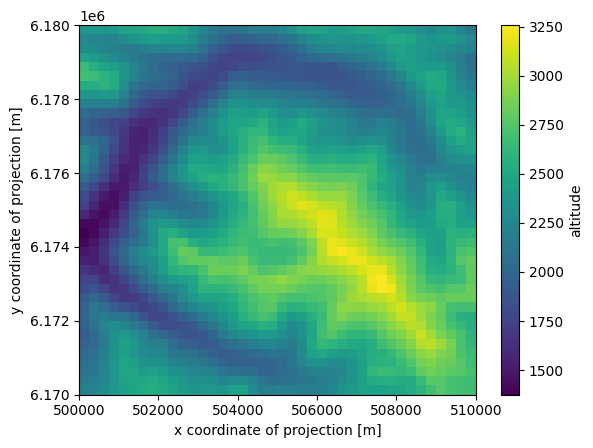

In [14]:
fic_topo = "/home/barroisl/LW base line/test_250.nc"

dem_path = "/home/barroisl/DEM_obj/DEM_FRANCE_L93_250m_bilinear.nc"
ds_topo = xr.open_dataset(dem_path)

ds_test = ds_topo.sel(x=slice(0.5e6, 0.51e6),y=slice(6.17e6,6.180e6))
ds_test.ZS.plot()

ds_test.to_netcdf(fic_topo)

## SW

A faire :

    Pour le ds_solar : préférer un calcul des elevation/azimuth à l'échelle de la maille AROME puis une 
    interpolation bilinéaire sur la maille cible, plus rapide sans doute...
    
    Travailler l'architecture du run dir et autour
    Faire le cas où un ou plusieurs xmin.. est None et pas les autres
    
    Tout tester sur un sous domaine
    
    Récupérer un fichier de forçage dans le grille d'intérêt... ou passer le dem dans la grille d'intérêt...
   
    
OK : 

    Faire le cas où sur le domaine les mask d'ombrage, les paramètres topo sont déjà donnés
    pour la projection mettre zéro si la projection est négative = self shadow
    Condition : si le fichier ds_solar et cosha existent déjà dans le répertoire ne pas les recalculer
    Fournir une direction de dossier et l'architecture est imposée
    
Test :

    test de la série ok

In [12]:
ds_solar = xr.open_dataset("/home/barroisl/LW base line/solar_pos.nc")
ds_ha = xr.open_dataset("/home/barroisl/LW base line/horizon_angle.nc")
ds_shadow = xr.open_dataset("/home/barroisl/LW base line/shadow.nc")

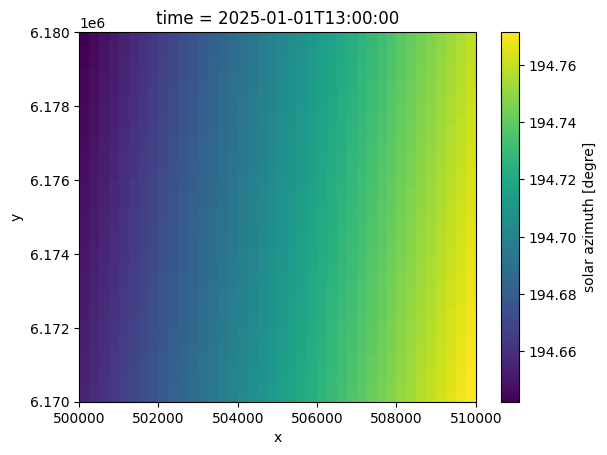

In [6]:
ds_solar.azimuth[1].plot()

In [10]:
ds_ha

<xarray.Dataset> Size: 5MB
Dimensions:  (azimuth: 360, y: 40, x: 40)
Coordinates:
  * azimuth  (azimuth) int64 3kB 0 1 2 3 4 5 6 7 ... 353 354 355 356 357 358 359
  * y        (y) float64 320B 6.17e+06 6.17e+06 6.171e+06 ... 6.18e+06 6.18e+06
  * x        (x) float64 320B 5.001e+05 5.004e+05 ... 5.096e+05 5.099e+05
Data variables:
    cosha    (azimuth, y, x) float64 5MB ...

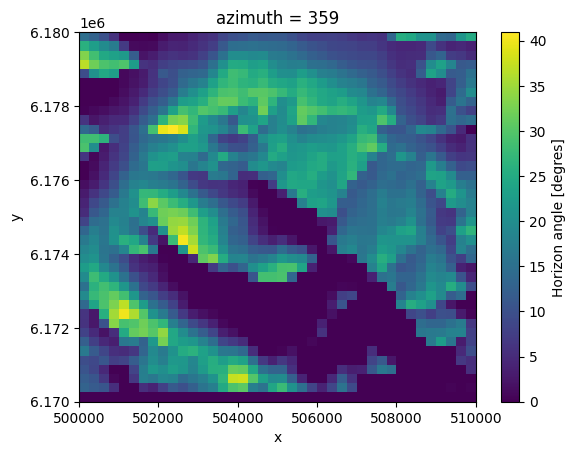

In [11]:
ds_ha.cosha[359].plot()

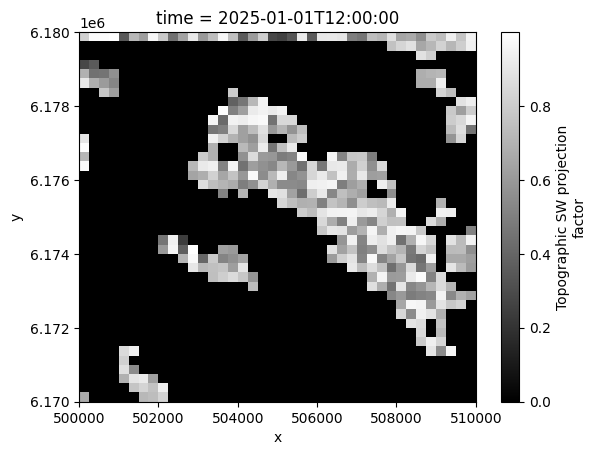

In [15]:
ds_shadow.shadow_mask[0].plot(cmap = 'binary_r')

In [2]:
############# Fonction de transfert topographique SW ###############

############# Utils ###################################

######## Select area ##########

def crop_dataset(
    fic_to_ds : str,
    epsg_i : int,
    epsg_ds : int,
    x_dim,
    y_dim,
    xmin = None,
    xmax = None,
    ymin = None,
    ymax = None,
    )-> xr.Dataset :
    
    ds = xr.open_dataset(fic_to_ds)
    
    # Reindexing on increasing coordinates 
    ds = ds.sortby(x_dim)
    #ds = ds.sortby(y_dim)
    
    if epsg_i != epsg_ds :
        xmin,ymin = convert_epsg_pts(xmin,ymin, epsg_src = epsg_i, epsg_tgt=epsg_ds)
        xmax,ymax = convert_epsg_pts(xmax,ymax, epsg_src = epsg_i, epsg_tgt=epsg_ds)
                
    ds = ds.sel({x_dim: slice(xmin, xmax), y_dim: slice(ymin, ymax)})
    
    return ds

def slice_by_time(ds: xr.Dataset,
                  start: str | pd.Timestamp,
                  stop:  str | pd.Timestamp,
                  dim: str = "valid_time") -> xr.Dataset:
    
    if dim not in ds.coords:
        raise KeyError(f"'{dim}' n’est pas une coordonnée du dataset "
                       f"(coordonnées disponibles : {list(ds.coords)})")

    start_ts = pd.to_datetime(start)
    stop_ts  = pd.to_datetime(stop)

    ds_slice = ds.sel({dim: slice(start_ts, stop_ts)})

    return ds_slice

######## Interpolation #########

@nb.njit()
def find_closest(arr: np.ndarray, 
                 val: float) -> int:
    """
    [Input]
    - array 1D rangé dans l'ordre croissant
    - valeur
    [Output]
    - index tel que arr[i] <= val < arr[i+1]
    """
    a, b = 0, arr.shape[0] - 2          # on veut l'index gauche
    while a < b:
        milieu = (a + b + 1) // 2
        if arr[milieu] <= val:
            a = milieu
        else:
            b = milieu - 1
    return a

@nb.njit()
def bilinear_interpolation(
    xs: np.ndarray, 
    ys: np.ndarray,
    arr: np.ndarray,
    points: np.ndarray,
    ) -> np.ndarray:
    """
    [Input]
    - coordonnées x de la grille (Nx,) triées croissantes
    - coordonnées y de la grille (Ny,) triées croissantes
    - array (Ny, Nx) des valeurs à interpoler pour chaque points de la grille 
    - points cibles (N, 3)  colonnes x, y, z
    
    [Output]
    - (N,) de valeurs SVF interpolées (NaN si hors grille)
    """
    N = points.shape[0]
    result = np.empty(N, dtype=np.float64)
 
    x_min, x_max = xs[0], xs[-1]
    y_min, y_max = ys[0], ys[-1]
 
    for k in range(N):
        px = points[k, 0]
        py = points[k, 1]
 
        # Hors domaine renvoit NaN
        if px < x_min or px > x_max or py < y_min or py > y_max:
            result[k] = np.nan
            continue
 
        ix = find_closest(xs, px)
        iy = find_closest(ys, py)
        
        # Renvoit un Nan si les proches voisins sont des Nan
        if (np.isnan(arr[iy,ix]) == True or arr[iy+1,ix+1] == True or
            arr[iy+1,ix] == True or arr[iy,ix+1] == True):
            
            result[k] = np.nan
            continue
            
        x0, x1 = xs[ix], xs[ix + 1]
        y0, y1 = ys[iy], ys[iy + 1]
 
        # Poids de pondération = distance relative à l'écart entre les proches voisins
        tx = (px - x0) / (x1 - x0)
        ty = (py - y0) / (y1 - y0)
 
        # Coins de la cellule  arr[iy, ix] → ligne = y, colonne = x
        res00 = arr[iy,     ix    ]
        res10 = arr[iy,     ix + 1]
        res01 = arr[iy + 1, ix    ]
        res11 = arr[iy + 1, ix + 1]
 
        result[k] = (
            res00 * (1 - tx) * (1 - ty)
            + res10 *      tx  * (1 - ty)
            + res01 * (1 - tx) *      ty
            + res11 *      tx  *      ty
        )
 
    return result

@nb.njit()
def interpolate(
    xs : np.ndarray,
    ys : np.ndarray,
    arr : np.ndarray,
    points: np.ndarray,
    ) -> np.ndarray:
    """
    [Input]
    - xs : valeurs 1D des abscisses du tableau
    - ys : valeurs 1D des ordonnées du tableau
    - arr : tableau 2D des valeurs à interpoler
    - points : ndarray des points où interpoler (Nbre_points, 2) (x,y)
    [Output]
    - np.ndarray (N,) de valeurs interpolées (Nan hors domaine)
    """
    
    # Garantit que les axes sont croissants pour si jamais sortie de xarray
    if xs[-1] < xs[0]:
        xs  = xs[::-1].copy()
        arr = arr[:, ::-1].copy()
    if ys[-1] < ys[0]:
        ys  = ys[::-1].copy()
        arr = arr[::-1, :].copy()
 
    pts = np.ascontiguousarray(points)#, dtype=np.float64)
 
    return bilinear_interpolation(xs, ys, arr, pts)

def convert_epsg_pts(xs,ys, epsg_src, epsg_tgt=32632):
    """
    Simple function to convert a list fo poitn from one projection to another oen using PyProj

    Args:
        xs (array): 1D array with X-coordinate expressed in the source EPSG
        ys (array): 1D array with Y-coordinate expressed in the source EPSG
        epsg_src (int): source projection EPSG code
        epsg_tgt (int): target projection EPSG code

    Returns: 
        array: Xs 1D arrays of the point coordinates expressed in the target projection
        array: Ys 1D arrays of the point coordinates expressed in the target projection
    """
    #print('Convert coordinates from EPSG:{} to EPSG:{}'.format(epsg_src, epsg_tgt))
    trans = Transformer.from_crs("epsg:{}".format(epsg_src), "epsg:{}".format(epsg_tgt), always_xy=True)
    Xs, Ys = trans.transform(xs, ys)
    return Xs, Ys

def compute_svf_regular_grid(
    fic_topo : str,
    fic_save : str,
    xmin : float,
    xmax : float,
    ymin : float,
    ymax : float,    
    epsg_i = 4326,
    epsg_ds = 2154,    
    ):
        
    ds_topo = crop_dataset(
        fic_to_ds = fic_topo,
        xmin = xmin,
        xmax = xmax,
        ymin = ymin,
        ymax = ymax,
        epsg_i = epsg_i,
        epsg_ds = epsg_ds,
        x_dim = "x",
        y_dim = "y"
        )
    
    dem_arr = ds_topo.ZS.values
    
    # La projection Lambert 93 (ou epsg 2154) est en mètre donc conforme pour le calcul, pas besoin de changer en 32632
    #xs, ys = convert_epsg_pts(ds_topo.x.values,ds_topo.x.values, epsg_src = epsg_init, epsg_tgt=32632)
    dx = np.median(np.diff(ds_topo.x.values))
    dy = np.median(np.diff(ds_topo.y.values))

    svf = viewf.viewf(np.double(dem_arr), dx)[0]
    slope, aspect = gradient.gradient_d8(dem_arr, dx, dy)
    
    # Sauvegarde sous .nc
    ds_topo_params = xr.Dataset(
        data_vars=dict(
            ZS=(["y", "x"], dem_arr.astype(np.float64)),
            svf=(["y", "x"], svf.astype(np.float64)),
            slope=(["y", "x"], slope.astype(np.float64)),
            aspect=(["y", "x"], aspect.astype(np.float64)),
        ),
        coords=dict(
            x=("x", ds_topo.x.values),
            y=("y", ds_topo.y.values),
        )
    )
    ds_topo_params.ZS.attrs={'units': 'm', 'standard_name': 'elevation', 'long_name': 'elevation'}
    ds_topo_params.x.attrs = {'units': 'm'}
    ds_topo_params.y.attrs = {'units': 'm'}
    ds_topo_params.slope.attrs = {'units': 'rad'}
    ds_topo_params.aspect.attrs = {'units': 'rad'}
    ds_topo_params.svf.attrs = {'units': 'ratio', 'standard_name': 'svf', 'long_name': 'Sky view factor'}
    
    ds_topo_params.to_netcdf(fic_save)

############# Position soleil et date #################

def from_dates_to_solar_angles(
    time_slice,
    fic_solar_pos : str,
    fic_dem : str,
    ):
    
    ds_topo = xr.open_dataset(fic_dem)
    
    xx,yy = np.meshgrid(ds_topo.x.values,ds_topo.y.values)
    lons,lats = convert_epsg_pts(xx,yy, epsg_src=2154, epsg_tgt=4326)
    
    nt,nx,ny = len(time_slice),lons.shape[0],lons.shape[1]
    solar_pos = np.zeros((nt, nx, ny,2))
    
    for t, timestamp in enumerate(time_slice):  
        solar = pvlib.solarposition.get_solarposition(
            latitude  = lats.ravel(),   # tableau 1D de tous les pixels
            longitude = lons.ravel(),
            time      = np.full_like(lats.ravel(),timestamp)

        )
        solar_pos[t, :, :, 0] = solar["azimuth"].values.reshape(nx, ny)
        solar_pos[t, :, :, 1] = solar["elevation"].values.reshape(nx, ny)
                
    ds_solar = xr.Dataset(
        data_vars=dict(
            elevation=(["time","y", "x"], solar_pos[:,:,:,1]),
            azimuth=(["time","y", "x"], solar_pos[:,:,:,0]),
        ),
        coords=dict(
            time=("time", time_slice),
            x=("x", ds_topo.x.values),
            y=("y", ds_topo.y.values),
        )
    )
    ds_solar.elevation.attrs={'units': 'degre', 'standard_name': 'elevation', 'long_name': 'solar elevation'}
    ds_solar.azimuth.attrs = {'units': 'degre', 'standard_name': 'azimuth', 'long_name': 'solar azimuth'}
    
    ds_solar.to_netcdf(fic_solar_pos)
    
######################## Projection et ombres ######################

@nb.njit(cache=True)
def proj(
    slope : float,
    aspect : float,
    azimuth : float,
    elevation : float,
    )-> float:
    
    fact = np.cos(np.pi/2 - elevation)*np.cos(slope) + np.sin(np.pi/2 - elevation)*np.sin(slope)*np.cos(azimuth - aspect)
    
    if fact > 0 : # fact < 0 : à l'ombre de sa propre pente
        return fact
    
    else :
        return 0

def horizon_angles_tab(
    DEM : np.ndarray,
    spacing : float,
    azimuths = np.arange(360),
    )->np.ndarray :

    a,b = DEM.shape
    cosha = np.zeros((len(azimuths),a,b))

    for i,azimuth in enumerate(azimuths):
        
        cosha[i,:,:] = horizon.horizon(azimuth-180,DEM.astype(np.float64),spacing) # Attention : où bien placer l'azimth zéro ?
        
    return cosha

@nb.njit(cache=True) 
def shadow(
    cosha : np.ndarray, # en degrés, 3D
    azimuths_t : np.ndarray, # en degrés, 3D
    elevations_t : np.ndarray, # cos(elevation) en degrés, 3D
    slope : np.ndarray,
    aspect : np.ndarray,
    )-> np.ndarray :
    
    _,a,b = cosha.shape
    res = np.ones((a,b))
    
    for i in range(a):
        for j in range(b):
            
            azi_index = int(round(azimuths_t[i,j])) % 360
                            
            if cosha[azi_index,i,j] > elevations_t[i,j] :
                res[i,j] = 0
                
            else :
                res[i,j] = proj(
                                slope = slope[i,j],
                                aspect = aspect[i,j],
                                azimuth = azimuths_t[i,j],
                                elevation = elevations_t[i,j])
    return res 

@nb.njit(cache=True)
def shadow_tab(
    cosha : np.ndarray, # np.ndarray (360,nx,ny)
    elevations : np.ndarray, # np.cos(elevation) np.ndarray (nt,nx,ny)
    azimuths : np.ndarray, # np.ndarray (nt,nx,ny)
    slope : np.ndarray, # np.ndarray (nx,ny)
    aspect : np.ndarray, # np.ndarray (nx,ny)
    )-> np.ndarray:
    
    nt,nx,ny = elevations.shape
    shad = np.ones((nt,nx,ny))
    
    for t in range(nt):
        
        shad[t,:,:] = shadow(
            cosha = cosha,
            azimuths_t = azimuths[t],
            elevations_t = elevations[t],
            slope = slope,
            aspect = aspect)
        
    return shad

def shadow_dataset(
    time_slice,
    ds_topo : xr.Dataset,
    fic_solar_pos : str,
    fic_ha : str,
    fic_shadow : str,
    fic_dem :str,
    force_recompute_solar = False,
    force_recompute_horizon = False
    ):
    
    dx = np.median(np.diff(ds_topo.x.values)) 
    xx, yy = np.meshgrid(ds_topo.x.values,ds_topo.y.values)
    
    # Changement systeme de coordonnées de Lambert 93 (epsg 2154) à epsg 4326 pour from_dates_to_solar_angles
    lons,lats = convert_epsg_pts(xx,yy, epsg_src=2154, epsg_tgt=4326)
    
    solar_exists = Path(fic_solar_pos).exists() and not force_recompute_solar
    if not solar_exists :
    
        path = Path(fic_solar_pos)
        path.unlink(missing_ok=True)
        
        from_dates_to_solar_angles(
            time_slice = time_slice,
            fic_dem = fic_dem,
            fic_solar_pos = fic_solar_pos)
    
    ds_solar = xr.open_dataset(fic_solar_pos)
    
    print("Solar features OK")
    
    horizon_exists = Path(fic_ha).exists() and not force_recompute_horizon
    if not horizon_exists :
        
        path = Path(fic_ha)
        path.unlink(missing_ok=True)
    
        cosha = horizon_angles_tab(
                    DEM = ds_topo.ZS.values,
                    spacing = dx)*(180/np.pi)

        # Sauvegarde sous .nc
        ds_ha = xr.Dataset(
            data_vars=dict(
                cosha=(["azimuth","y", "x"], cosha)
            ),
            coords=dict(
                azimuth=("azimuth", np.arange(360)),
                y=("y", ds_topo.y.values),
                x=("x", ds_topo.x.values),
            )
        )
        ds_ha.cosha.attrs={'units': 'degres','standard_name': 'Horizon angle', 'long_name': 'Horizon angle'}
        ds_ha.to_netcdf(fic_ha)
        
    ds_ha = xr.open_dataset(fic_ha)
    
    print("Horizon angles OK")
    
    shadows = shadow_tab(
        cosha = ds_ha.cosha.values,
        elevations = np.cos(ds_solar.elevation.values*(np.pi/180)),
        azimuths = ds_solar.azimuth.values,
        slope = ds_topo.slope.values,
        aspect = ds_topo.aspect.values)
    
    # Sauvegarde sous .nc
    ds_shadow = xr.Dataset(
        data_vars=dict(
            shadow_mask=(["time","y", "x"], shadows[:,:,:])
        ),
        coords=dict(
            time=("time", time_slice),
            x=("x", ds_topo.x.values),
            y=("y", ds_topo.y.values),
        )
    )
    ds_shadow.shadow_mask.attrs={'standard_name': 'Topo SW proj', 'long_name': 'Topographic SW projection factor'}
    ds_shadow.to_netcdf(fic_shadow)
    
    print("Shadow mask OK")

############# Utilisation ############################

def Baseline_SW(
    run_dir : str,
    xmin : float, # en epsg 4326 pour matcher le forçage AROME
    ymin : float,
    xmax : float,
    ymax : float,
    start_time : str | pd.Timestamp,
    end_time : str | pd.Timestamp,
    x_dim_AROME = "longitude",
    y_dim_AROME = "latitude",
    time_dim = "valid_time",
    force_recompute_topo_params = False,
    force_recompute_shadows = False,
    force_recompute_solar = False,
    force_recompute_horizon = False,
    ):
    
    run_dir = Path(run_dir)
    fic_forcage = run_dir / "forcing.nc"
    fic_dem = run_dir / "dem.nc"
    fic_topo_params = run_dir / "topo_params.nc"
    fic_shadow = run_dir / "shadow.nc"
    fic_res = run_dir / "SW.nc"
    
    # Error on missing file in working directory
    
    try:
        xr.open_dataset(fic_forcage).close()
        xr.open_dataset(fic_dem).close()
        #xr.open_dataset(fic_dem_pre_cropped).close()
    except FileNotFoundError as e:
        raise FileNotFoundError(f"Fichier manquant dans le répertoire de run : {e}") from e
                
    # Opening DEM
    
    """
    dem_cropped_exists = Path(fic_dem).exists() and not force_recompute_DEM_cut
    if not dem_cropped_exists :
        
        path = Path(fic_dem)
        path.unlink(missing_ok=True)
        
        xmin_dem,ymin_dem = convert_epsg_pts(xmin,ymin, epsg_src = 4326, epsg_tgt=2154)
        xmax_dem,ymax_dem = convert_epsg_pts(xmax,ymax, epsg_src = 4326, epsg_tgt=2154)

        ds_dem = crop_dataset(
            fic_to_ds = fic_dem_pre_cropped,
            xmin = xmin_dem,
            xmax = xmax_dem,
            ymin = ymin_dem,
            ymax = ymax_dem,
            x_dim = "x",
            y_dim = "y",
            epsg_i = 2154,
            epsg_ds = 2154)
    
        ds_dem.to_netcdf(fic_dem)
    
    print("DEM crop OK")
    """
            
    # Opening meteorological forçing file
    ds_forcage = crop_dataset(
        fic_to_ds = fic_forcage,
        xmin = xmin-0.1,
        xmax = xmax+0.1,
        ymin = ymin-0.1,
        ymax = ymax+0.1,
        x_dim = x_dim_AROME,
        y_dim = y_dim_AROME,
        epsg_i = 4326,
        epsg_ds = 4326)
    
    ds_forcage = slice_by_time(ds_forcage,
                  start = start_time,
                  stop = end_time,
                  dim = time_dim)
            
    # Changement systeme de coordonnées de epsg 4326 à Lambert 93 (epsg 2154)
    xx,yy = np.meshgrid(ds_forcage[x_dim_AROME].values,ds_forcage[y_dim_AROME].values)
    xs_, ys_ = convert_epsg_pts(xx,yy, epsg_src =4326, epsg_tgt=2154)
    xs, ys = xs_[0],ys_[:,0]
        
    print("Forcing file OK")
    
    topo_params_exists = Path(fic_topo_params).exists() and not force_recompute_topo_params
    if not topo_params_exists :
        
        path = Path(fic_topo_params)
        path.unlink(missing_ok=True)
        
        compute_svf_regular_grid(
            fic_topo = fic_dem,
            fic_save = fic_topo_params,
            xmin = np.min(xs),
            xmax = np.max(xs),
            ymin = np.min(ys),
            ymax = np.max(ys), 
            epsg_i = 2154,
            epsg_ds = 2154)
        
    # Reopening the file with the SVF variable
    ds_topo = xr.open_dataset(fic_topo_params)
        
    print("Topo file OK")
    
    shadow_exists = Path(fic_shadow).exists() and not force_recompute_shadows
    if not shadow_exists:
        
        path = Path(fic_shadow)
        path.unlink(missing_ok=True)
    
        time_slice = ds_forcage.valid_time.values
        fic_solar_pos = run_dir / 'ds_solar.nc'
        fic_ha = run_dir / 'horizon_angle.nc'

        shadow_dataset(
            time_slice = time_slice,
            ds_topo = ds_topo,
            fic_solar_pos = fic_solar_pos,
            fic_ha = fic_ha,
            fic_shadow = fic_shadow,
            fic_dem = fic_topo_params,
            force_recompute_solar = force_recompute_solar,
            force_recompute_horizon = force_recompute_horizon)
        
        print("Shadow file OK")
        
    # Ouverture données ombrage     
    ds_shadow = xr.open_dataset(fic_shadow)
    
    # Les points pour les interpolations
    xx,yy = np.meshgrid(ds_topo.x.values,ds_topo.y.values)
    nx,ny = xx.shape
    points = np.column_stack((np.ravel(xx),np.ravel(yy)))
    
    SW_fine = np.zeros((len(ds_forcage[time_dim].values),nx,ny,2))
    
    for i,t in enumerate(ds_forcage[time_dim].values):
        
        ds_forcage_t = ds_forcage.sel({time_dim : t})
        ds_shadow_t = ds_shadow.sel({'time' : t},method='nearest')
        
        SW_fine[i,:,:,0] = interpolate( 
            xs = xs,
            ys = ys,
            arr = ds_forcage_t.SWdir.values, #.astype(np.float64),
            points = points).reshape(nx, ny)*ds_shadow_t.shadow_mask.values
        
        SW_fine[i,:,:,1] = interpolate( 
            xs = xs,
            ys = ys,
            arr = ds_forcage_t.SWdif.values, #.astype(np.float64),
            points = points).reshape(nx, ny)*ds_topo.svf.values
        
    # Sauvegarde sous .nc
    ds_SW = xr.Dataset(
        data_vars=dict(
            SWdir=(["time","y", "x"], SW_fine[:,:,:,0]),
            SWdif=(["time","y", "x"], SW_fine[:,:,:,1])
        ),
        coords=dict(
            time=("time", ds_forcage[time_dim].values),
            x=("x", ds_topo.x.values),
            y=("y", ds_topo.y.values),
        )
    )
    
    ds_SW.SWdir.attrs={'units': '$W.m^{-2}$', 'standard_name': 'SWdir', 'long_name': 'Direct downwelling shortwave'}
    ds_SW.SWdif.attrs={'units': '$W.m^{-2}$', 'standard_name': 'SWdif', 'long_name': 'Diffuse downwelling shortwave'}
    
    path = Path("/home/barroisl/radiation_baseline/SW.nc")
    path.unlink(missing_ok=True)
    
    ds_SW.to_netcdf(fic_res)
    
    print("SW OK")

## Create fake forçing file : uniforme for several time values on the lon,lat grid

In [19]:
# Creating a fake forçing for testing 

fic_forcage = "/home/barroisl/Data/inputs/climate/yearly/981408a01c93699ff3bde9bdcd856c6d/data_stream-oper_stepType-instant.nc"
ds_forcage = xr.open_dataset(fic_forcage)

SWdir = xr.DataArray(
    np.full_like(ds_forcage.t2m.values,300, dtype = np.float64),
    dims=('valid_time', 'latitude', 'longitude'),
    name='SWdir'
)

SWdif = xr.DataArray(
    np.full_like(ds_forcage.t2m.values,60, dtype = np.float64),
    dims=('valid_time', 'latitude', 'longitude'),
    name='SWdif'
)

ds_forcage['SWdir'] = SWdir
ds_forcage['SWdif'] = SWdif

"""
ds_forcage = ds_forcage.rename({"latitude" : "x", "longitude" : "y"})
ds_forcage = ds_forcage.rename({"y" : "latitude", "x" : "longitude"})
"""

ds_forcage['longitude'] = np.linspace(5.19,6.28,4)
ds_forcage['latitude'] = np.linspace(44.77,45.37,4)

path = Path("/home/barroisl/radiation_baseline/forcing.nc")
path.unlink(missing_ok=True)

ds_forcage.to_netcdf(path)

In [17]:
ds_forcage = xr.open_dataset("/home/barroisl/radiation_baseline/forcing.nc")

## Testing existing code

In [3]:
# Si le les points du DEM sont en dehors de la grille de forçage, l'interpolation bilinéaire donnera une 
# valeur np.nan . Pour éviter ce problème la sélection du DEM se fait sur les longitude, latitude
# du forçage

run_dir =  "/home/barroisl/radiation_baseline/"

ds_forcage = xr.open_dataset(run_dir + "forcing.nc")
xmin = min(ds_forcage.longitude.values)
xmax = max(ds_forcage.longitude.values)
ymin = min(ds_forcage.latitude.values)
ymax = max(ds_forcage.latitude.values)

print(xmin,xmax,ymin,ymax)

Baseline_SW(
    run_dir = run_dir,
    xmin = xmin,
    ymin = ymin,
    xmax = xmax,
    ymax = ymax,
    start_time = '2025-01-01T12:00:00.000000000',
    end_time = '2025-01-01T21:00:00.000000000',
    x_dim_AROME = "longitude",
    y_dim_AROME = "latitude",
    time_dim = 'valid_time',
    force_recompute_topo_params = False,
    force_recompute_solar = False,
    force_recompute_shadows = True,
    force_recompute_horizon = False)

5.19 6.28 44.77 45.37
Forcing file OK
Topo file OK
Solar features OK
Horizon angles OK
Shadow mask OK
Shadow file OK
SW OK


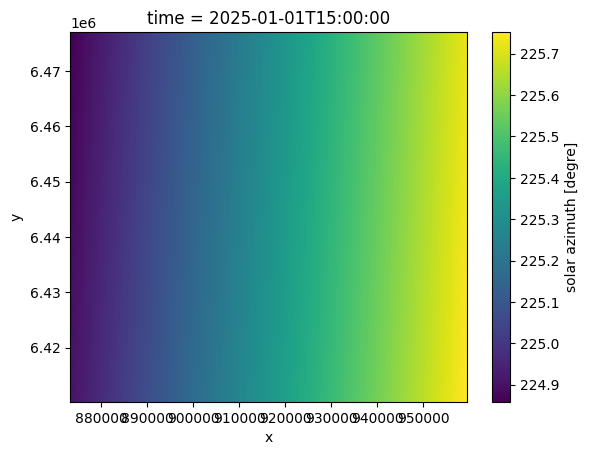

In [8]:
ds_solar = xr.open_dataset("/home/barroisl/radiation_baseline/ds_solar.nc")
ds_solar.azimuth[3].plot()

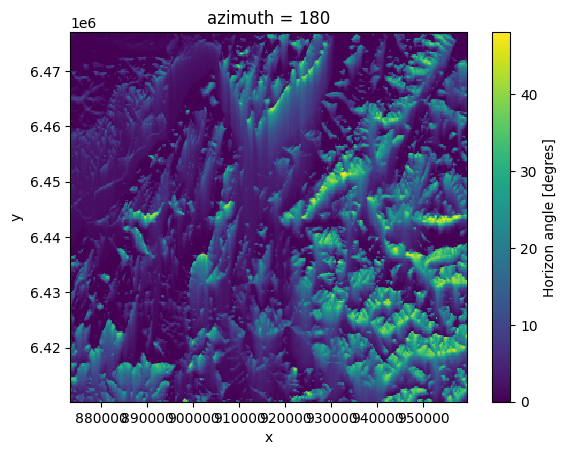

In [12]:
ds_ha = xr.open_dataset("/home/barroisl/radiation_baseline/horizon_angle.nc")
ds_ha.cosha[180].plot()

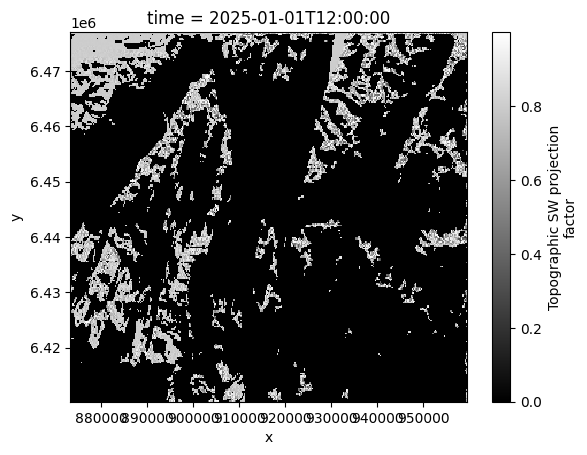

In [20]:
shadow = xr.open_dataset("/home/barroisl/radiation_baseline/shadow.nc")
shadow.shadow_mask[0].plot(cmap = "binary_r")

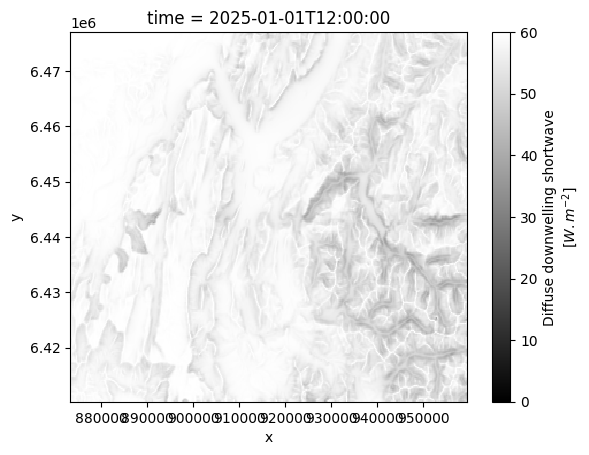

In [24]:
SW = xr.open_dataset("/home/barroisl/radiation_baseline/SW.nc")
SW.SWdif[0].plot(cmap = 'binary_r', vmin = 0, vmax = 60)

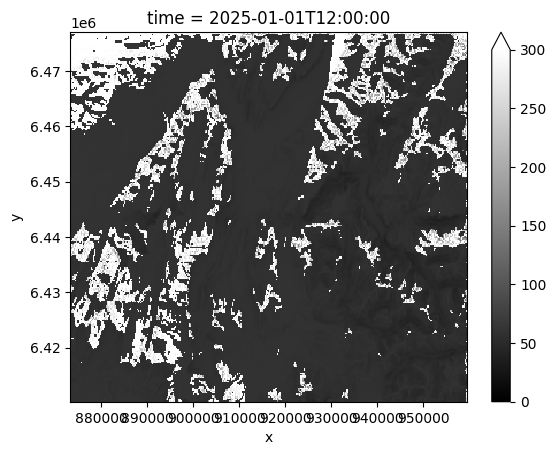

In [26]:
(SW.SWdif[0]+SW.SWdir[0]).plot(cmap = 'binary_r', vmin = 0, vmax = 300)

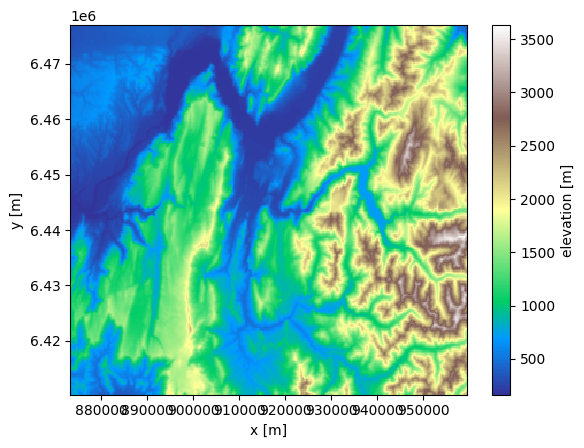

In [24]:
topo_params = xr.open_dataset("/home/barroisl/radiation_baseline/topo_params.nc")
topo_params.ZS.plot(cmap = 'terrain')

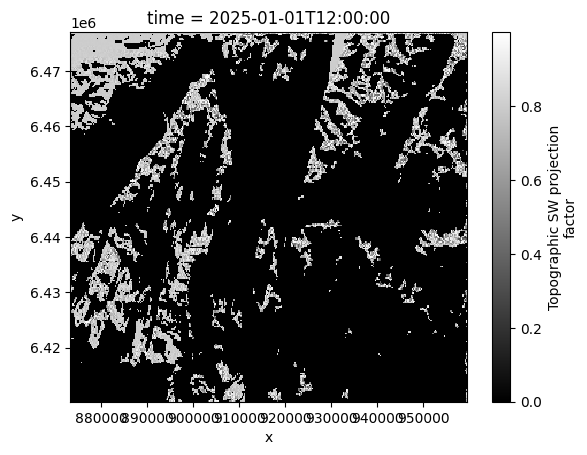

In [25]:
shadows = xr.open_dataset("/home/barroisl/radiation_baseline/shadow.nc")
shadows.shadow_mask[0].plot(cmap = 'binary_r')

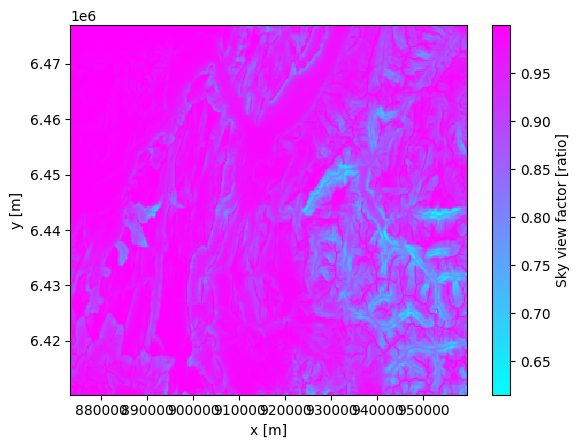

In [13]:
topo = xr.open_dataset("/home/barroisl/radiation_baseline/topo_params.nc")
topo.svf.plot(cmap = 'cool')